# Postselection with bit-flip checks

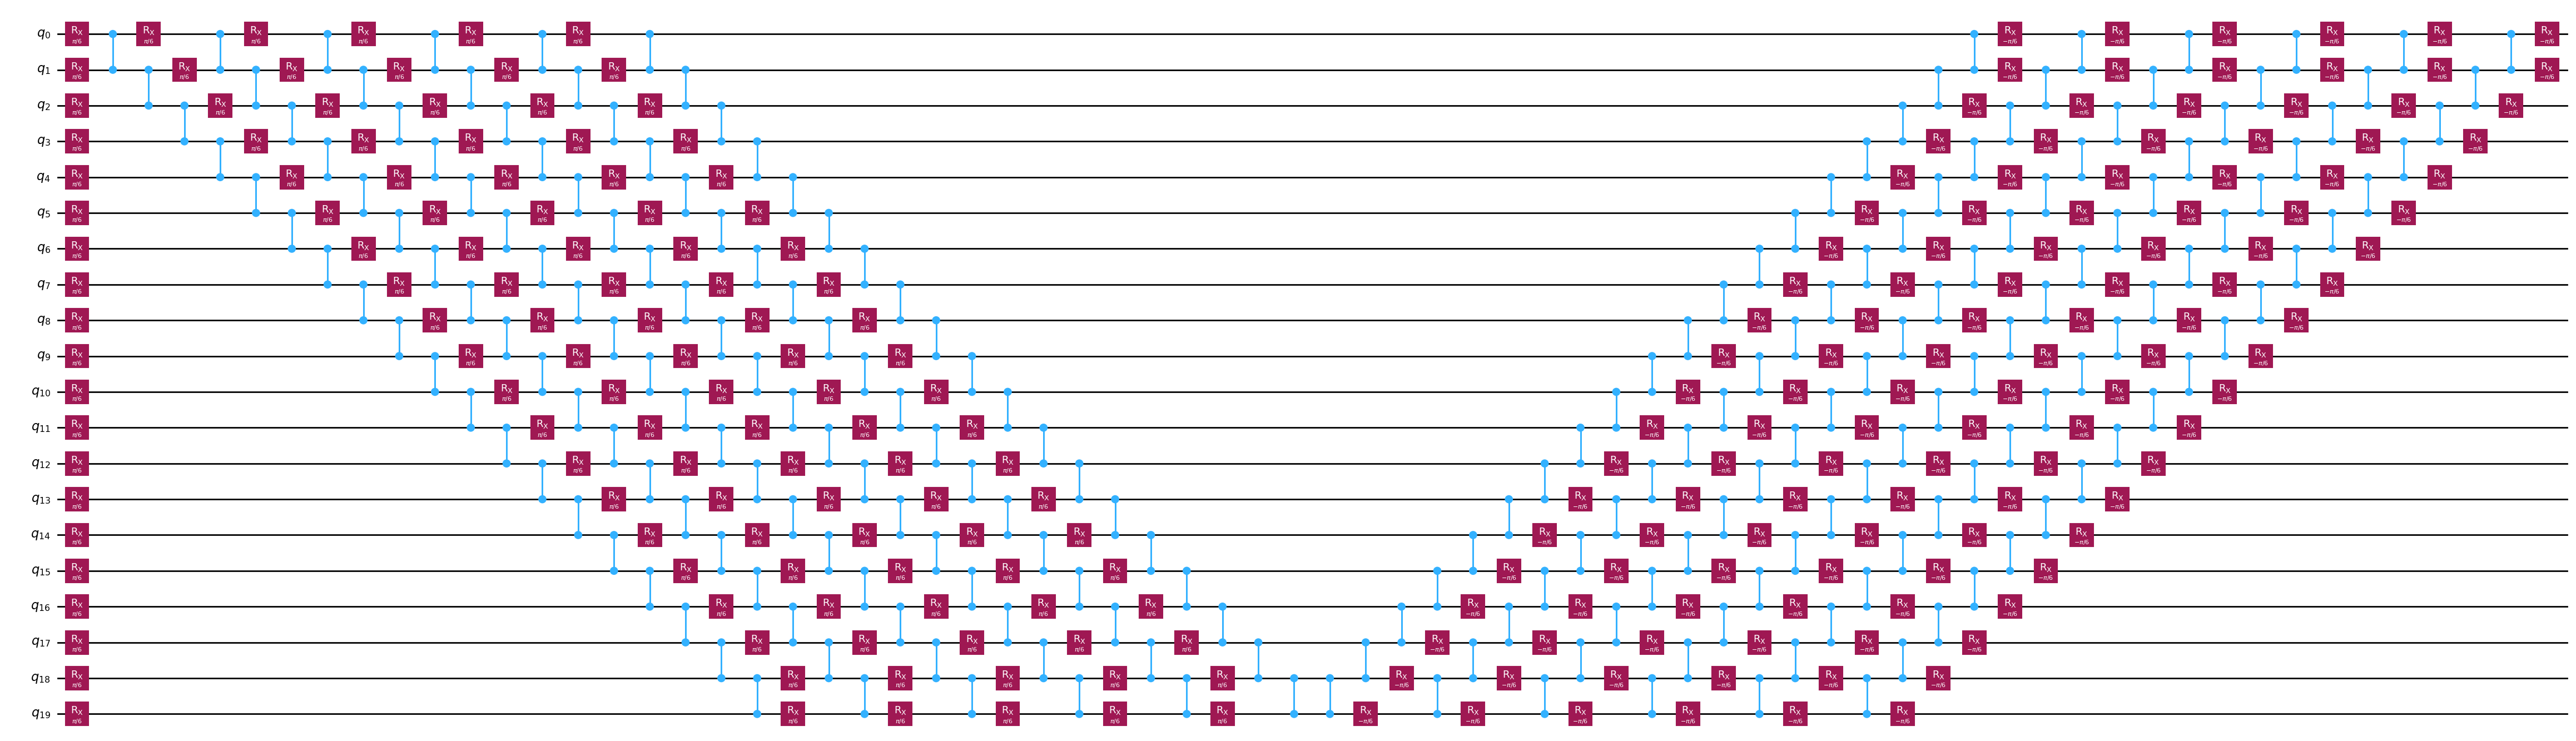

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import CouplingMap

num_qubits = 20
initial_layout = initial_layout = [
    124,
    125,
    126,
    127,
    128,
    129,
    130,
    131,
    132,
    133,
    134,
    135,
    139,
    155,
    154,
    153,
    152,
    151,
    150,
    149,
][:num_qubits]
coupling_map = CouplingMap.from_line(num_qubits, bidirectional=False)

# Num Trotter steps
num_steps = 6
theta_rx = np.pi / 6
mirror = True

# Average single-site magnetization
observable = (
    SparsePauliOp(["I" * iq + "Z" + "I" * (num_qubits - iq - 1) for iq in range(num_qubits)])
    / num_qubits
)

# Create the Trotter circuit
circuit = QuantumCircuit(num_qubits)
edges = CouplingMap.from_line(num_qubits, bidirectional=False).get_edges()
for _ in range(num_steps):
    circuit.rx(theta_rx, [i for i in range(num_qubits)])
    for edge in edges:
        circuit.cz(edge[0], edge[1])
if mirror:
    circuit = circuit.compose(circuit.inverse())
circuit.draw("mpl", fold=-1, filename="mirror_ising.png")

In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(channel="ibm_quantum_platform", instance="services-premium-us")
backend = service.backend("ibm_boston")
print(f"backend: {backend.name}  |  qubits: {backend.num_qubits}")
print(backend)

backend: ibm_boston  |  qubits: 156
<IBMBackend('ibm_boston')>


In [3]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Append terminal measurements (creates a classical register named "meas").
meas_circuit = circuit.copy()
meas_circuit.measure_all()

pm = generate_preset_pass_manager(
    optimization_level=0, backend=backend, initial_layout=initial_layout
)
isa_circuit = pm.run(meas_circuit)

print(f"two-qubit depth: {isa_circuit.depth(lambda instr: instr.operation.num_qubits == 2)}")
print(f"total depth:     {isa_circuit.depth()}")

two-qubit depth: 58
total depth:     119


In [4]:
from qiskit.transpiler import PassManager
from qiskit_addon_utils.noise_management.bit_flip_checks.passes import (
    AddPostCircuitBitFlipChecks,
    AddPreCircuitBitFlipChecks,
    AddSpectatorPostCircuitBitFlipChecks,
    AddSpectatorPreCircuitBitFlipChecks,
)

# Combined pre + post bit-flip checks (both with spectators). A single run of this circuit carries
# every check register (meas_pre/spec_pre for pre, meas_ps/spec/spec_ps for post), so every
# pass combination is recoverable in post-processing. Passes run on the laid-out circuit with
# the backend coupling map; rx pulses are translated to the basis at opt level 0 (no relayout,
# no merging).
combined = PassManager(
    [
        AddPreCircuitBitFlipChecks(x_pulse_type="rx"),
        AddSpectatorPreCircuitBitFlipChecks(backend.coupling_map, x_pulse_type="rx"),
        AddPostCircuitBitFlipChecks(x_pulse_type="rx"),
        AddSpectatorPostCircuitBitFlipChecks(backend.coupling_map, x_pulse_type="rx"),
    ]
).run(isa_circuit)
combined_isa = generate_preset_pass_manager(optimization_level=0, backend=backend).run(combined)

print("cregs:", [(c.name, c.size) for c in combined_isa.cregs])

cregs: [('meas', 20), ('meas_pre', 20), ('spec_pre', 7), ('meas_ps', 20), ('spec', 7), ('spec_ps', 7)]


In [5]:
from qiskit_ibm_runtime import Executor, QuantumProgram

# Raw and combined-checks circuits in a single 100k-shot program so they share calibration.
program = QuantumProgram(shots=100_000)
program.append_circuit_item(isa_circuit)  # raw circuit, no checks
program.append_circuit_item(combined_isa)  # combined pre + post bit-flip checks
job = Executor(backend).run(program)
print(f"job id: {job.job_id()}")
print(f"status: {job.status()}")

job id: d98fjsif47jc73a7s3k0
status: QUEUED


In [ ]:
from qiskit_addon_utils.noise_management.bit_flip_checks import PostSelector

selector = PostSelector.from_circuit(combined_isa, backend.coupling_map)

exec_results = job.result()
# The Executor returns numpy arrays keyed by classical-register name, so each result item is
# already the {creg_name: ndarray} mapping that compute_mask expects -- no BitArray unpacking.
raw_bits = exec_results[0]["meas"]  # raw circuit, no checks
bits = exec_results[1]  # combined pre+post circuit

meas_bits = bits["meas"]
total = meas_bits[..., 0].size


def magnetization(b, mask=None):
    """Average single-site magnetization over the (optionally masked) measurement bits."""
    kept = b if mask is None else b[mask]
    return (1 - 2 * kept.astype(int)).mean()  # bit 0 -> +1, bit 1 -> -1


rows = []


def report(label, mask=None, b=meas_bits):
    """Record and print the magnetization and kept fraction for one selection strategy."""
    kept = b[..., 0].size if mask is None else int(mask.sum())
    ev = magnetization(b, mask)
    rows.append((label, ev, kept / total))
    print(f"{label:<24}: <m> = {ev:+.4f}   (kept {kept:>6}/{total})")


# Every pass combination is recoverable from this single run.
report("raw circuit", b=raw_bits)
report("no selection")
for s in ("node", "edge"):
    report(f"pre-only ({s})", selector.compute_mask(bits, s, mode="pre"))
for s in ("node", "edge"):
    report(f"post-only ({s})", selector.compute_mask(bits, s, mode="post"))
for pre_s in ("node", "edge"):
    for post_s in ("node", "edge"):
        keep = selector.compute_mask(bits, pre_s, mode="pre") & selector.compute_mask(
            bits, post_s, mode="post"
        )
        report(f"pre={pre_s} + post={post_s}", keep)

In [ ]:
import matplotlib.pyplot as plt

labels = [r[0] for r in rows]
evs = [r[1] for r in rows]
fracs = [r[2] for r in rows]
x = range(len(labels))

fig, ax1 = plt.subplots(figsize=(11, 5))

# Bars: expectation value per selection strategy.
ax1.bar(x, evs, color="steelblue", alpha=0.85)
ax1.axhline(rows[0][1], color="gray", ls="--", lw=1, label="raw <m>")  # raw baseline
ax1.set_ylabel("<m>  (avg single-site magnetization)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.set_xticks(list(x))
ax1.set_xticklabels(labels, rotation=45, ha="right")
ax1.legend(loc="upper left")

# Line: fraction of shots retained (right axis).
ax2 = ax1.twinx()
ax2.plot(x, fracs, "o-", color="darkorange")
ax2.set_ylabel("kept fraction", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")
ax2.set_ylim(0, 1.05)

ax1.set_title("Selection strategy: expectation value vs shots retained")
fig.tight_layout()
plt.savefig("ps_chart.png", dpi=300)